In [10]:
from joblib import load

model = load(r"E:\LogAnomalyDetector\models\best_model.joblib")
vectorizer = load(r"E:\LogAnomalyDetector\models\tfidf_vectorizer.joblib")

print("Loaded new model and vectorizer.")


Loaded new model and vectorizer.


In [11]:
import pandas as pd

df_hdfs = pd.read_csv(r"E:\LogAnomalyDetector\data\external_datasets\hdfs_upload_ready.csv")

print("HDFS dataset shape:", df_hdfs.shape)
print("\nLabel distribution (ground truth):")
print(df_hdfs["true_label"].value_counts())


HDFS dataset shape: (200, 6)

Label distribution (ground truth):
true_label
0    195
1      5
Name: count, dtype: int64


In [12]:
X_text = df_hdfs["message"].astype(str)
y_true = df_hdfs["true_label"].astype(int)

print("Total samples:", len(X_text))


Total samples: 200


In [14]:
X_features = vectorizer.transform(X_text)

print("Feature shape:", X_features.shape)


Feature shape: (200, 300)


In [15]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_features)

print("Predicted label distribution:")
import numpy as np
print("Predicted Normal:", (y_pred == 0).sum())
print("Predicted Anomaly:", (y_pred == 1).sum())

print("\nConfusion Matrix on HDFS Dataset:")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


Predicted label distribution:
Predicted Normal: 200
Predicted Anomaly: 0

Confusion Matrix on HDFS Dataset:
[[195   0]
 [  5   0]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9750    1.0000    0.9873       195
           1     0.0000    0.0000    0.0000         5

    accuracy                         0.9750       200
   macro avg     0.4875    0.5000    0.4937       200
weighted avg     0.9506    0.9750    0.9627       200



C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dayus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

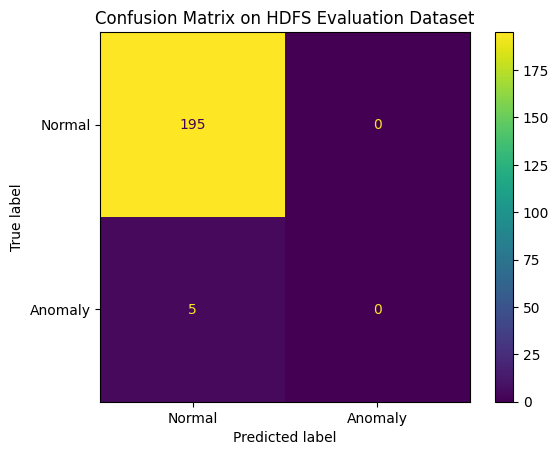

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix on HDFS Evaluation Dataset")
plt.show()


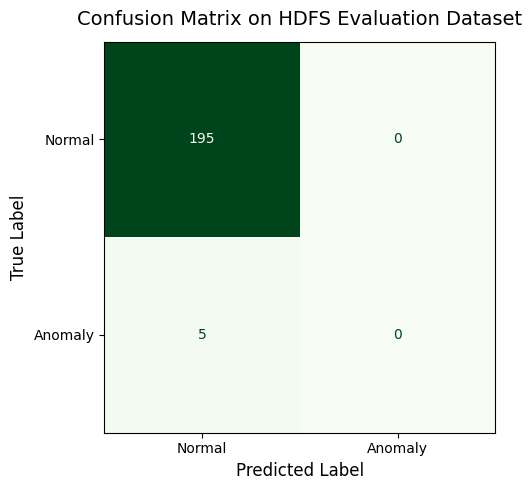

Saved HDFS confusion matrix to:
E:\LogAnomalyDetector\reports\confusion_matrix_hdfs.png


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(values_format="d", cmap="Greens", ax=plt.gca(), colorbar=False)

plt.title("Confusion Matrix on HDFS Evaluation Dataset", fontsize=14, pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()

# Save for report
plt.savefig(r"E:\LogAnomalyDetector\reports\confusion_matrix_hdfs.png", dpi=300)

plt.show()

print("Saved HDFS confusion matrix to:")
print(r"E:\LogAnomalyDetector\reports\confusion_matrix_hdfs.png")
